# 신용카드 사기 탐지 분류 문제

이 노트북의 다음 라이브러리 버전은 "파이썬 머신러닝 완벽 가이드 개정2판"을 기준으로 설정되었습니다.

### 라이브러리 버전
2. `xgboost` : 1.5.0
3. `lightgbm` : 3.3.2

### 기타 사용 라이브러리
1. `hyperopt`

In [ ]:
# 다시 깨끗하게 지우고
!pip uninstall -y xgboost lightgbm numpy pandas

# 버전 지정 없이 최신 버전으로 설치 (코랩 최적화)
!pip install xgboost lightgbm numpy pandas

In [6]:
# !pip uninstall -y pandas
# !pip install pandas==1.5.3 xgboost==1.5.0 lightgbm==3.3.2

Found existing installation: pandas 1.5.3
Uninstalling pandas-1.5.3:
  Successfully uninstalled pandas-1.5.3
  Using cached pandas-1.5.3-cp312-cp312-linux_x86_64.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
spopt 0.7.0 requires pandas>=2.1.0, but you have pandas 1.5.3 which is incompatible.
tobler 0.13.0 requires pandas>=2.2, but you have pandas 1.5.3 which is incompatible.
geopandas 1.1.2 requires pandas>=2.0.0, but you have pandas 1.5.3 which is incompatible.
libpysal 4.14.1 requires pandas>=2.1.0, but you have pandas 1.5.3 which is incompatible.
esda 2.8.1 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.
mapclassify 2.10.0 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you h

In [4]:
!pip install hyperopt

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import xgboost
import lightgbm

print(f"Pandas 버전: {pd.__version__}")
print(f"XGBoost 버전: {xgboost.__version__}")

# 훈련 데이터와 테스트 데이터는 미리 준비되어 있습니다.

train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv', on_bad_lines='skip', low_memory=False)

Pandas 버전: 3.0.0
XGBoost 버전: 3.1.3


# 데이터셋 정보

2013년 9월 유럽 신용카드 사용자들의 거래 내역을 포함하고 있습니다.
이 데이터셋은 이틀 간의 거래 내역으로 데이터셋은 크게 불균형하며, 사기 거래(양성 클래스)는 전체 거래의 약 0.17%에 불과합니다.

이 데이터셋은 PCA 변환을 거친 수치형 변수들만 포함하고 있습니다. 안타깝게도 기밀 유지 문제로 인해 원본 특징과 데이터에 대한 자세한 배경 정보는 제공할 수 없습니다. V1, V2, …, V28은 PCA로 얻은 주성분이며, PCA 변환을 거치지 않은 유일한 특징은 'Time'과 'Amount'입니다. 'Time'은 각 거래와 데이터셋의 첫 거래 사이의 경과 시간(초)을 나타내며, 'Amount'는 거래 금액입니다. 'Amount' 특징은 예시 의존적 비용 민감 학습 등에 사용될 수 있습니다. 'Class'는 응답 변수로, 사기 거래인 경우 1, 그렇지 않은 경우 0의 값을 가집니다.

클래스 불균형 비율을 고려하여, 정밀도-재현율 곡선 아래 영역(AUPRC)을 사용하여 정확도를 측정할 것을 권장합니다. 불균형 분류에서는 혼동 행렬 정확도가 큰 의미가 없습니다.

이 데이터셋은 Worldline과 ULB(브뤼셀 자유 대학교) 머신러닝 그룹(http://mlg.ulb.ac.be) 간의 빅데이터 마이닝 및 사기 탐지 관련 연구 협력을 통해 수집 및 분석되었습니다.
관련 주제에 대한 현재 및 과거 프로젝트에 대한 자세한 내용은 https://www.researchgate.net/project/Fraud-detection-5 및 DefeatFraud 프로젝트 페이지에서 확인할 수 있습니다.

In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170883 entries, 0 to 170882
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      170883 non-null  int64  
 1   Time    170883 non-null  float64
 2   V1      170883 non-null  float64
 3   V2      170883 non-null  float64
 4   V3      170883 non-null  float64
 5   V4      170883 non-null  float64
 6   V5      170883 non-null  float64
 7   V6      170883 non-null  float64
 8   V7      170883 non-null  float64
 9   V8      170883 non-null  float64
 10  V9      170883 non-null  float64
 11  V10     170883 non-null  float64
 12  V11     170883 non-null  float64
 13  V12     170883 non-null  float64
 14  V13     170883 non-null  float64
 15  V14     170883 non-null  float64
 16  V15     170883 non-null  float64
 17  V16     170883 non-null  float64
 18  V17     170883 non-null  float64
 19  V18     170883 non-null  float64
 20  V19     170883 non-null  float64
 21  V20     170883 non-nu

In [3]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113923 entries, 0 to 113922
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      113923 non-null  int64  
 1   Time    113923 non-null  float64
 2   V1      113923 non-null  float64
 3   V2      113923 non-null  float64
 4   V3      113923 non-null  float64
 5   V4      113923 non-null  float64
 6   V5      113923 non-null  float64
 7   V6      113923 non-null  float64
 8   V7      113923 non-null  float64
 9   V8      113923 non-null  float64
 10  V9      113923 non-null  float64
 11  V10     113923 non-null  float64
 12  V11     113923 non-null  float64
 13  V12     113923 non-null  float64
 14  V13     113923 non-null  float64
 15  V14     113923 non-null  float64
 16  V15     113923 non-null  float64
 17  V16     113923 non-null  float64
 18  V17     113923 non-null  float64
 19  V18     113923 non-null  float64
 20  V19     113923 non-null  float64
 21  V20     113923 non-nu

In [4]:
train_df.describe()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,...,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000,170883.000000
mean,85441.000000,61091.567090,-0.169838,0.040771,0.493037,0.117429,-0.176102,0.058235,-0.080669,0.032227,...,-0.028287,-0.083744,-0.022450,0.009008,0.092269,0.012603,0.002093,0.002445,87.336704,0.002107
std,49329.817362,27828.109419,1.850529,1.610874,1.383241,1.371910,1.338609,1.295123,1.208518,1.227630,...,0.743713,0.667318,0.584508,0.598760,0.465505,0.490660,0.391951,0.307315,245.954429,0.045851
min,0.000000,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,42720.500000,41216.500000,-0.986667,-0.539174,-0.064747,-0.743475,-0.828769,-0.691129,-0.586314,-0.162638,...,-0.230722,-0.546777,-0.170294,-0.332459,-0.195933,-0.330346,-0.065125,-0.027054,5.480000,0.000000
50%,85441.000000,60776.000000,-0.183560,0.109679,0.623352,0.124307,-0.226228,-0.202634,-0.031932,0.056664,...,-0.054462,-0.066786,-0.036211,0.059474,0.135662,-0.058966,0.008693,0.021152,21.890000,0.000000
75%,128161.500000,78622.000000,1.184446,0.804221,1.297352,0.937632,0.374445,0.449200,0.462616,0.350995,...,0.128337,0.363165,0.098707,0.415860,0.399458,0.272938,0.089727,0.078302,76.720000,0.000000
max,170882.000000,120396.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [5]:
test_df.describe()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,...,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000,113923.000000
mean,227844.000000,145396.169808,0.254759,-0.061154,-0.739555,-0.176137,0.264150,-0.087346,0.120988,-0.048337,...,-0.046430,0.042428,0.125609,0.033672,-0.013512,-0.138398,-0.018897,-0.003140,-0.003667,89.867850
std,32886.881696,14553.200321,2.084808,1.708359,1.402141,1.461789,1.399511,1.381543,1.269186,1.140927,...,0.831851,0.718441,0.788888,0.678614,0.615591,0.567769,0.468657,0.420530,0.361528,256.236008
min,170883.000000,120396.000000,-46.855047,-50.383269,-48.325589,-5.683171,-113.743307,-20.869626,-23.386192,-39.688571,...,-54.497720,-21.620120,-7.417140,-36.666000,-2.790479,-8.696627,-1.855355,-9.895244,-15.430084,0.000000
25%,199363.500000,132928.500000,-0.803531,-0.691506,-1.598860,-0.978315,-0.437285,-0.880171,-0.491675,-0.273015,...,-0.247537,-0.223898,-0.534543,-0.142571,-0.382480,-0.450968,-0.313872,-0.075609,-0.062317,5.950000
50%,227844.000000,145247.000000,0.117889,-0.005846,-0.734520,-0.337083,0.250458,-0.389808,0.153525,-0.035902,...,-0.104920,0.036139,0.186973,0.040791,0.016358,-0.193153,-0.041566,-0.009555,-0.028507,22.450000
75%,256324.500000,157639.500000,1.978707,0.803286,0.121444,0.431529,0.882923,0.309498,0.746755,0.285891,...,0.091959,0.253758,0.750595,0.227957,0.524460,0.221885,0.214766,0.093824,0.078238,78.000000
max,284805.000000,172788.000000,2.454930,12.730564,3.937048,15.304184,29.162172,73.301626,120.589494,12.766112,...,23.643417,20.063786,8.272233,22.528412,4.584549,6.070850,3.415636,31.612198,16.129609,25691.160000


/tmp/ipython-input-1980022478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=train_df, palette='viridis')


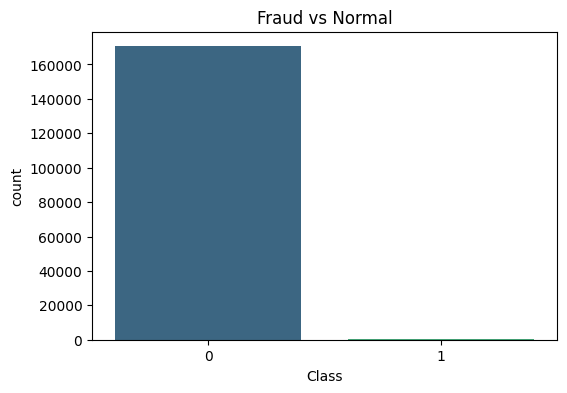

In [6]:
# 막대그래프
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title('Fraud vs Normal')
plt.show()

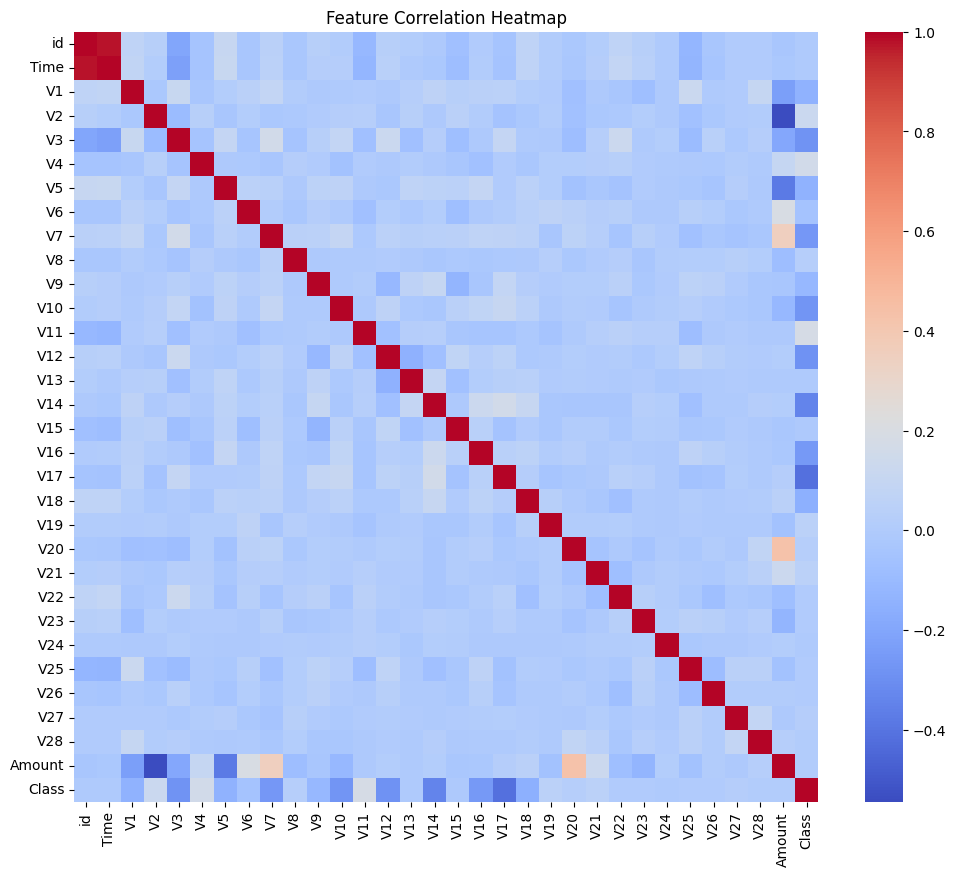

In [7]:
# 히트맵: 상관관계 분석
plt.figure(figsize=(12, 10))
corr = train_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

/tmp/ipython-input-3557114919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train_df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3557114919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train_df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3557114919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=train_df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3557114919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

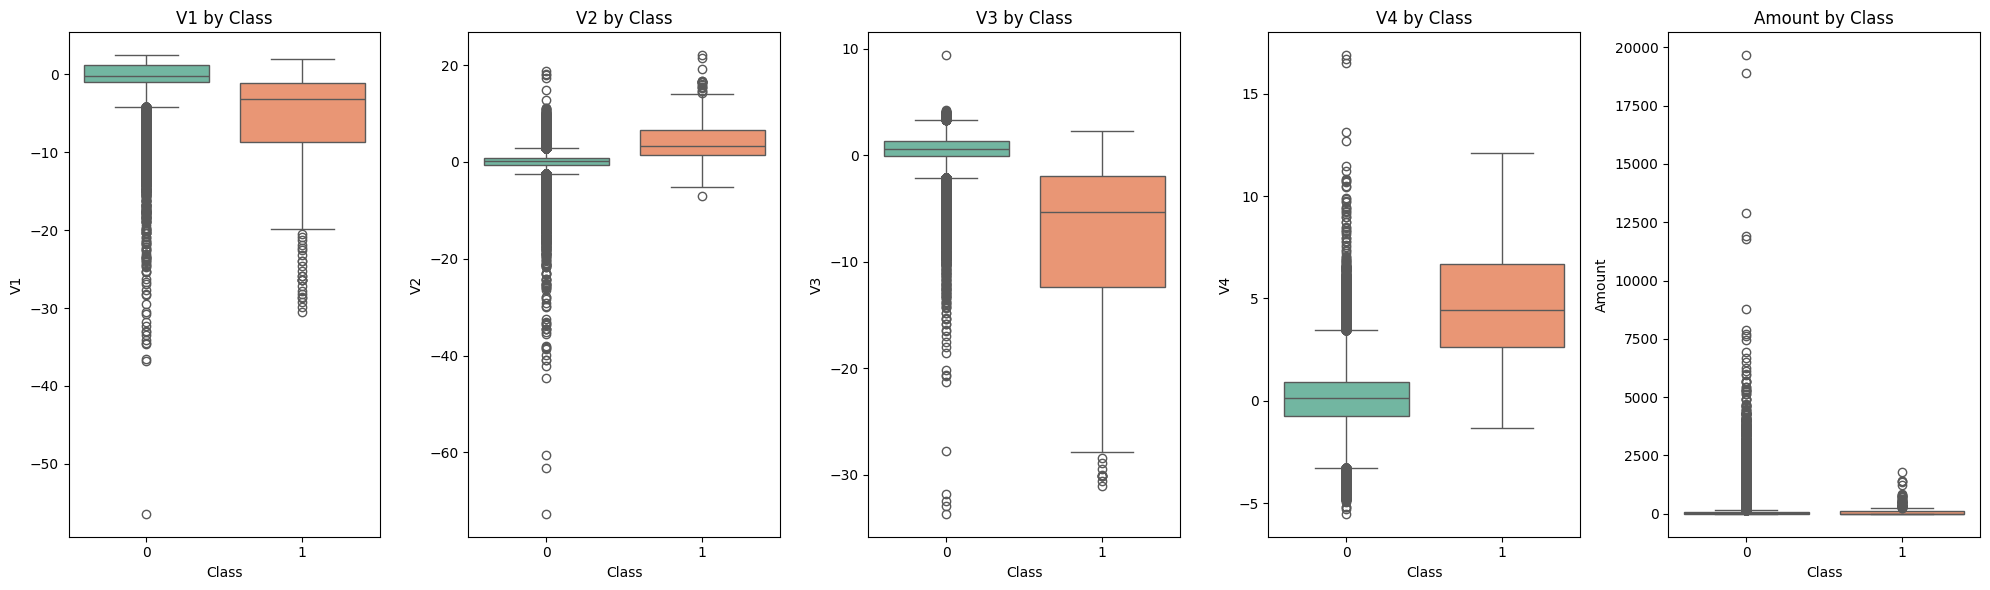

In [8]:
# 박스플롯
features = ['V1', 'V2', 'V3', 'V4', 'Amount']
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))
for i, col in enumerate(features):
    sns.boxplot(x='Class', y=col, data=train_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Class')

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# 특정 컬럼의 이상치 인덱스를 찾는 함수
def get_outlier(df=None, column=None, weight=1.5):
    # 사기 데이터(Class==1)만 추출
    fraud = df[df['Class']==1][column]

    # Q1, Q3 및 IQR 계산
    q1 = np.percentile(fraud.values, 25)
    q3 = np.percentile(fraud.values, 75)
    iqr = q3 - q1

    # 한계선 설정
    low_limit = q1 - (iqr * weight)
    high_limit = q3 + (iqr * weight)

    # 한계선을 벗어나는 데이터의 인덱스 반환
    outlier_idx = fraud[(fraud < low_limit) | (fraud > high_limit)].index
    return outlier_idx

# V17 컬럼에서 이상치 찾기
outlier_indices = get_outlier(df=train_df, column='V17', weight=1.5)
print("삭제할 이상치 인덱스:", outlier_indices.values)

# 이상치 삭제하기
train_df.drop(outlier_indices, axis=0, inplace=True)

삭제할 이상치 인덱스: []


# 뼈대 만들기

머신러닝 파이프라인은

데이터 준비 → 모델 정의 → 학습 → 예측 → 평가의 형태를 띕니다.

최소한의 형태로 파이프라인만 구성해 보겠습니다.

In [10]:
train_copy = train_df.copy()
train_copy.drop('Time', axis=1, inplace=True)

In [11]:
X_features = train_copy.iloc[:, :-1]
y_target = train_copy.iloc[:, -1]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_features, y_target, test_size=0.2, random_state=42, stratify=y_target)

In [13]:
print('학습 데이터 간 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('검증 데이터 간 레이블 값 비율')
print(y_val.value_counts()/y_val.shape[0] * 100)

학습 데이터 간 레이블 값 비율
Class
0    99.789329
1     0.210671
Name: count, dtype: float64
검증 데이터 간 레이블 값 비율
Class
0    99.789332
1     0.210668
Name: count, dtype: float64


In [14]:
from sklearn.linear_model import LogisticRegression

# 로지스틱 학습
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

# 검증
lr_val = lr_clf.predict(X_val)
lr_val_proba = lr_clf.predict_proba(X_val)[:,1]

print('학습 완료!')

학습 완료!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_val_confusion = confusion_matrix(y_val, lr_val)
lr_val_accuracy = accuracy_score(y_val, lr_val)
lr_val_precision = precision_score(y_val, lr_val)
lr_val_recall = recall_score(y_val, lr_val)
lr_val_f1 = f1_score(y_val, lr_val)

lr_val_roc_score = roc_auc_score(y_val, lr_val_proba)
print(lr_val_roc_score)

print("검증 데이터 혼동행렬:")
print(lr_val_confusion)
print("검증 데이터 정확도: ",lr_val_accuracy)
print("검증 데이터 정밀도: ",lr_val_precision)
print("검증 데이터 재현율: ",lr_val_recall)
print("검증 데이터 F1 점수: ",lr_val_f1)
print("검증 데이터 AUC: ",lr_val_roc_score)


0.9590150515564677
검증 데이터 혼동행렬:
[[34092    13]
 [   32    40]]
검증 데이터 정확도:  0.9986833250431577
검증 데이터 정밀도:  0.7547169811320755
검증 데이터 재현율:  0.5555555555555556
검증 데이터 F1 점수:  0.64
검증 데이터 AUC:  0.9590150515564677


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# xgboost 모델 / 가중치와 학습깊이 조정 후 AUC 소폭 상승
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=10,
                        scale_pos_weight=500, random_state=42)

xgb_clf.fit(X_train.values, y_train.values)

# 예측
xgb_val_preds = xgb_clf.predict(X_val.values)
xgb_val_proba = xgb_clf.predict_proba(X_val.values)[:, 1]

# 결과
print('--- XGBoost 검증 성적표 ---')
print(f"혼동행렬:\n{confusion_matrix(y_val, xgb_val_preds)}")
print(f"정확도: {accuracy_score(y_val, xgb_val_preds):.4f}")
print(f"정밀도: {precision_score(y_val, xgb_val_preds):.4f}")
print(f"재현율: {recall_score(y_val, xgb_val_preds):.4f}")
print(f"F1 점수: {f1_score(y_val, xgb_val_preds):.4f}")
print(f"AUC: {roc_auc_score(y_val, xgb_val_proba):.4f}")

--- XGBoost 검증 성적표 ---
혼동행렬:
[[34101     4]
 [    9    63]]
정확도: 0.9996
정밀도: 0.9403
재현율: 0.8750
F1 점수: 0.9065
AUC: 0.9756


In [21]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# LightGBM 모델
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1,
                          boost_from_average=False, scale_pos_weight=100, random_state=42)

# 개별 모델 학습
lgbm_clf.fit(X_train, y_train)

# 기반 모델
base_models = [
    ('lr', lr_clf), # 로지스틱
    ('xgb', xgb_clf), # XGBoost
    ('lgbm', lgbm_clf) # LightGBM
]

# 스태킹 모델 최종 결정권자 = 로지스틱
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

# 학습 및 예측
stack_clf.fit(X_train, y_train)
stack_preds = stack_clf.predict(X_val)

[LightGBM] [Info] Number of positive: 288, number of negative: 136418
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.143514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 136706, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 288, number of negative: 136418
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 136706, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Info] Number of positive: 230, number of negative: 109134
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 109364, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# stack_clf로 예측
stack_preds = stack_clf.predict(X_val)
stack_proba = stack_clf.predict_proba(X_val)[:, 1]

# 결과
print('--- 최종 스태킹(Stacking) 검증 성적표 ---')
print(f"혼동행렬:\n{confusion_matrix(y_val, stack_preds)}")
print(f"정확도: {accuracy_score(y_val, stack_preds):.4f}")
print(f"정밀도: {precision_score(y_val, stack_preds):.4f}")
print(f"재현율: {recall_score(y_val, stack_preds):.4f}")
print(f"F1 점수: {f1_score(y_val, stack_preds):.4f}")
print(f"AUC: {roc_auc_score(y_val, stack_proba):.4f}")

--- 최종 스태킹(Stacking) 검증 성적표 ---
혼동행렬:
[[34105     0]
 [   11    61]]
정확도: 0.9997
정밀도: 1.0000
재현율: 0.8472
F1 점수: 0.9173
AUC: 0.9616


In [30]:
if 'Time' in test_df.columns:
    X_test_features = test_df.drop(['Time'], axis=1)
else:
    X_test_features = test_df.copy()


# 예측
xgb_clf_prob = xgb_clf.predict(X_test_features)

# 제출용 DataFrame
submission = pd.DataFrame({
    "id": test_df["id"],   # 반드시 원래 test.csv에 있던 id 사용
    "Class": xgb_clf_prob
})

# csv 파일 저장
submission.to_csv("./submission.csv", index=False)
print("파일 생성")
# print(submission['Class'].value_counts())

파일 생성


In [31]:
submission


,id,Class
0,170883,0
1,170884,0
2,170885,0
3,170886,0
4,170887,0
...,...,...
113918,284801,0
113919,284802,0
113920,284803,0
113921,284804,0


성능을 극대화를 위해 스태킹(Stacking) 앙상블까지 구현해 봤습니다. 그러나 검증 데이터로 비교해 보니 XGBoost 단일 모델의 AUC가 더 높고 사기 탐지 개수도 더 합리적임을 알 수 있었습니다.